In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [87]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [88]:
X = df[['displacement']]
Y = df['mpg']
print("Missing values in",X.isnull().sum())
print("missing values in mpg",Y.isnull().sum())

Missing values in displacement    0
dtype: int64
missing values in mpg 0


In [89]:
data = df[['displacement','mpg']].dropna()
X = data[['displacement']]
Y = data['mpg']
print("Feature:")
print(X.head())
print("\nTarget:")
print(Y.head())
      

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


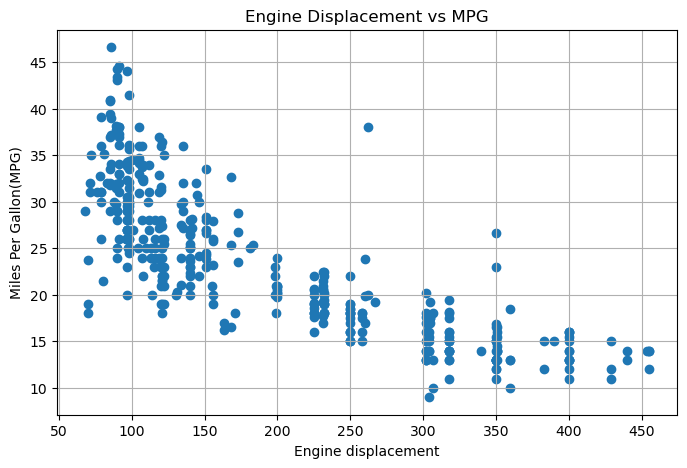

In [90]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.xlabel("Engine displacement")
plt.ylabel("Miles Per Gallon(MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()


In [91]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)
print("Traning samples:",len(X_train))
print("Testing samples:",len(X_test))

Traning samples: 318
Testing samples: 80


In [92]:
linear_model = LinearRegression()
linear_model.fit(X_train,Y_train)
Y_pred_linear = linear_model.predict(X_test)

In [93]:
mse_linear = mean_squared_error(Y_test,Y_pred_linear)
r2_linear = r2_score(Y_test,Y_pred_linear)
print("Linear Regression Results")
print("\n")
print("MSE:",mse_linear)
print("R-Squared:",r2_linear)

Linear Regression Results


MSE: 18.102543998358946
R-Squared: 0.6633114869465595


In [94]:
results = []
polynomial_models = {}
results.append({
    'Model':'Linear Regression',
    'Degree': 1,
    'MSE':mse_linear,
    'R-Squared':r2_linear
    })
for degree in range(2,6):
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model=LinearRegression()
    poly_model.fit(X_train_poly,Y_train)
    Y_pred_poly = poly_model.predict(X_test_poly)
    mse = mean_squared_error(Y_test,Y_pred_poly)
    r2  = r2_score(Y_test,Y_pred_poly)
    results.append({
        'Model':'Polynomial Regression','Degree':degree,'MSE':mse,'R-Squared':r2})
    polynomial_models[degree]={
        'poly':poly,
         'model':poly_model}

In [95]:
results_df = pd.DataFrame(results)
results_df

,Model,Degree,MSE,R-Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


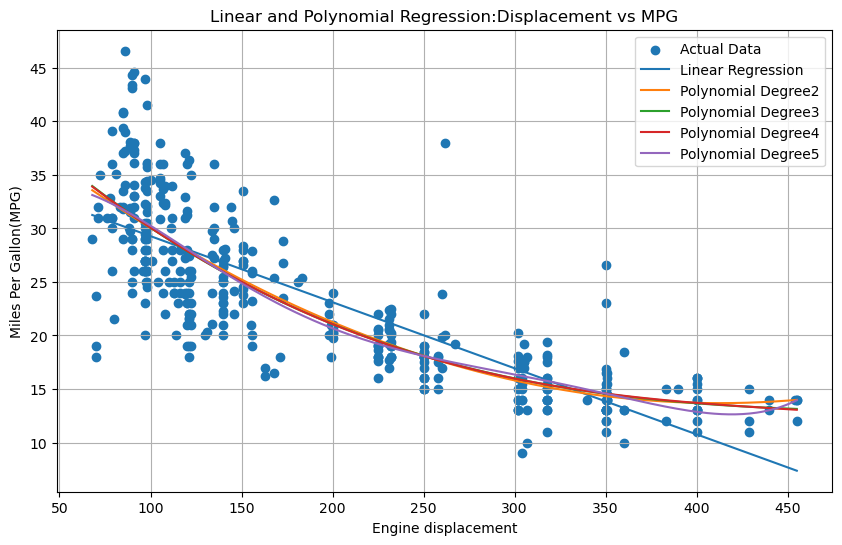

In [96]:
X_plot = pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)})
plt.figure(figsize=(10,6))
plt.scatter(
    X['displacement'],Y,label = 'Actual Data')

Y_plot_linear= linear_model.predict(X_plot)
plt.plot(
    X_plot['displacement'],
    Y_plot_linear,
    label='Linear Regression'
)
for degree in range(2,6):
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']
    X_plot_poly = poly.transform(X_plot)
    Y_plot_poly = poly_model.predict(X_plot_poly)
    plt.plot(
        X_plot['displacement'],
        Y_plot_poly,
        label = f'Polynomial Degree{degree}'
    )
plt.xlabel('Engine displacement')
plt.ylabel('Miles Per Gallon(MPG)')
plt.title(
    'Linear and Polynomial Regression:Displacement vs MPG')
plt.legend()
plt.grid()
plt.show()
    
    

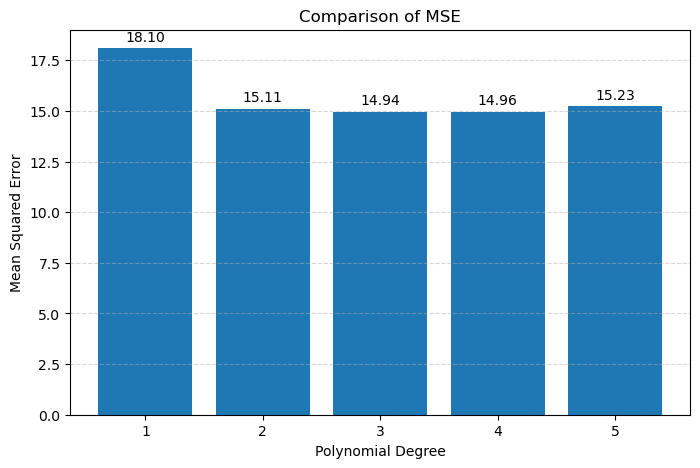

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE'])
plt.bar_label(bars,fmt ='%.2f',padding=3)
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()    

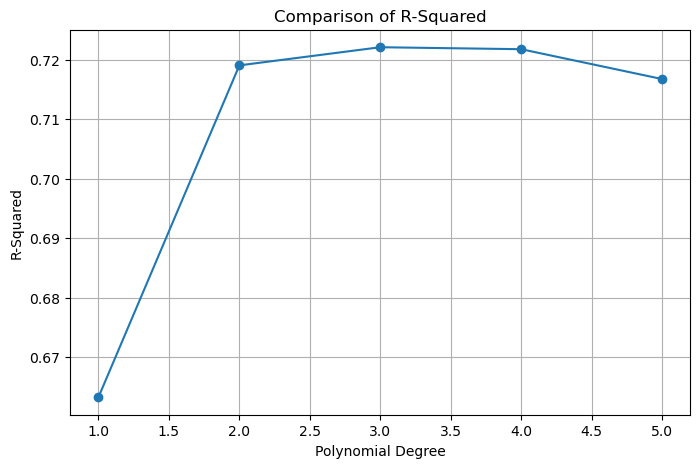

In [98]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-Squared'],
    marker='o'
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-Squared")
plt.title("Comparison of R-Squared")
plt.grid(True)
plt.show()